<a href="https://colab.research.google.com/github/cahyoadi-hash/praktikum-struktur-data/blob/main/Modul_10_(Dijkstra).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install network matplotlib

  Preparing metadata (setup.py) ... done
  Created wheel for network: filename=network-0.1-py3-none-any.whl size=3138 sha256=983c4876ef19de1d732e852e60972a5b97b031ef7acc79e4260ae68bb71623c6
  Stored in directory: /root/.cache/pip/wheels/e7/5a/7a/7f15bea66afb5505b9d10cc7bd8964cb77f0ce736df5b104c8
Successfully built network


jarak dari A ke Z : 14
Rute yang dilewati : A -> B -> D -> E -> Z


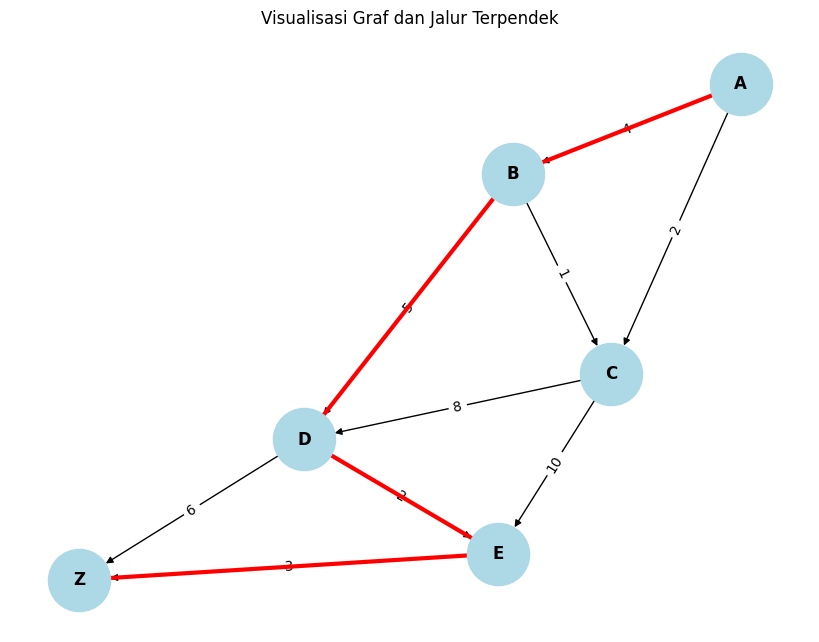

In [ ]:

#Membuat struktur data dan algoritma Djikstra
import heapq
import networkx as nx
import matplotlib.pyplot as plt

#djikstra
def djikstra(graph, start_node):
  distances = {node : float('inf') for node in graph}
  distances[start_node] = 0
  previous = {node : None for node in graph}
  queue = [(0, start_node)]

  while queue:
    current_distance, current_node = heapq.heappop(queue)

    for neighbor, weight in graph [current_node].items():
      new_distance = current_distance + weight
      if new_distance < distances[neighbor]:
        distances[neighbor] = new_distance
        previous[neighbor] = current_node
        heapq.heappush(queue, (new_distance, neighbor))

  return distances, previous

#merekontruksi jalur
def get_path(previous, target):
  path = []
  while target is not None:
    path.insert(0, target)
    target = previous[target]
  return path


#Visualisasi dengan networkx dan matplotlib
def visualize_graph(graph, path=None):
  G = nx.DiGraph()

  for node in graph:
    for neighbor, weight in graph[node].items():
      G.add_edge(node, neighbor, weight=weight)

  pos = nx.spring_layout(G)
  edge_labels = nx.get_edge_attributes(G, 'weight')

  plt.figure(figsize=(8, 6))
  nx.draw(G ,pos, with_labels=True, node_color='lightblue', node_size = 2000, font_weight='bold', arrows=True)
  nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

  #garis tabel untuk jalur terpendek
  if path and len(path) > 1:
        path_edges = list(zip(path, path[1:]))
        nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=3)

  plt.title("Visualisasi Graf dan Jalur Terpendek")
  plt.axis('off')
  plt.show()

#definisi graf
graph = {
    'A' : {'B': 4, 'C': 2},
    'B' : {'C': 1, 'D': 5},
    'C' : {'D': 8, 'E': 10},
    'D' : {'E': 2, 'Z': 6},
    'E' : {'Z': 3},
    'Z' : {}
}

#jalankan djikstra
start_node = 'A'
end_node = 'Z'
distance, previous = djikstra(graph, start_node)

#rekonstruksi jalur
shortest_path = get_path(previous, end_node)
print(f"jarak dari {start_node} ke {end_node} : {distance[end_node]}")
print(f"Rute yang dilewati : {' -> '.join(shortest_path)}")

#visualisasi
visualize_graph(graph, path=shortest_path)

---== TUGAS ==---

jarak dari A ke Z : 8
Rute yang dilewati : A -> C -> F -> Z


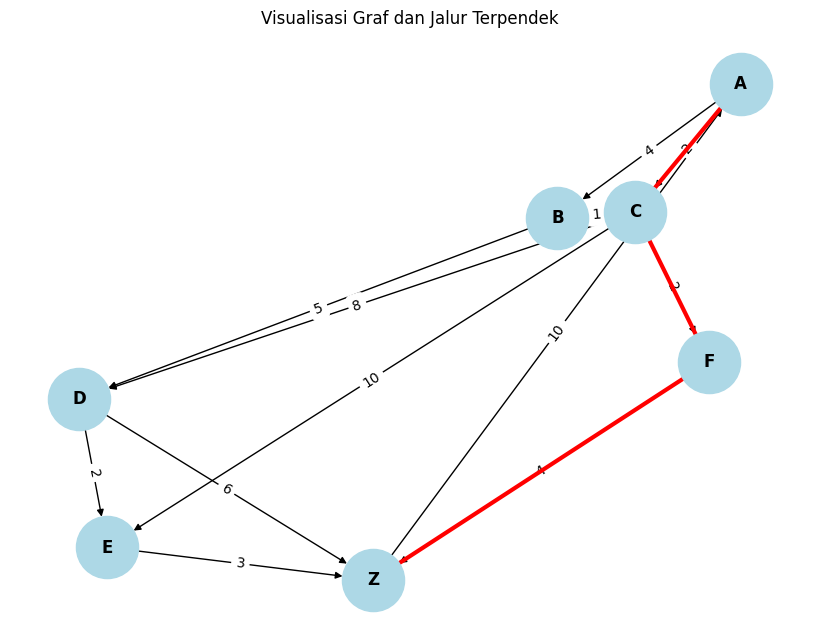

In [ ]:
print("---== TUGAS ==---\n")
#Membuat struktur data dan algoritma Djikstra
import heapq
import networkx as nx
import matplotlib.pyplot as plt

#djikstra
def djikstra(graph, start_node):
  distances = {node : float('inf') for node in graph}
  distances[start_node] = 0
  previous = {node : None for node in graph}
  queue = [(0, start_node)]

  while queue:
    current_distance, current_node = heapq.heappop(queue)

    for neighbor, weight in graph [current_node].items():
      new_distance = current_distance + weight
      if new_distance < distances[neighbor]:
        distances[neighbor] = new_distance
        previous[neighbor] = current_node
        heapq.heappush(queue, (new_distance, neighbor))

  return distances, previous

#merekontruksi jalur
def get_path(previous, target):
  path = []
  while target is not None:
    path.insert(0, target)
    target = previous[target]
  return path


#Visualisasi dengan networkx dan matplotlib
def visualize_graph(graph, path=None):
  G = nx.DiGraph()

  for node in graph:
    for neighbor, weight in graph[node].items():
      G.add_edge(node, neighbor, weight=weight)

  #Soal 3 : Ganti tata letak graf dengan pos = nx.circular_layout (G) atau kamada_kawai layout.
  pos = nx.kamada_kawai_layout(G)
  edge_labels = nx.get_edge_attributes(G, 'weight')

  plt.figure(figsize=(8, 6))
  nx.draw(G ,pos, with_labels=True, node_color='lightblue', node_size = 2000, font_weight='bold', arrows=True)
  nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

  #garis tabel untuk jalur terpendek
  if path and len(path) > 1:
        path_edges = list(zip(path, path[1:]))
        nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=3)

  plt.title("Visualisasi Graf dan Jalur Terpendek")
  plt.axis('off')
  plt.show()

#Soal 1 : Modifikasi graf agar memiliki siklus dan ulangi visualisasinya.
graph = {
    'A' : {'B': 4, 'C': 2},
    'B' : {'C': 1, 'D': 5},
    'C' : {'D': 8, 'E': 10, 'F': 2},
    'D' : {'E': 2, 'Z': 6},
    'E' : {'Z': 3},
    #Soal 2 : Tambahkan simpul baru dan lihat bagaimana jalur terpendek berubah.
    'F' : {'Z': 4},
    'Z' : {'A': 10}
}


#jalankan djikstra
start_node = 'A'
end_node = 'Z'
distance, previous = djikstra(graph, start_node)

#rekonstruksi jalur
shortest_path = get_path(previous, end_node)
print(f"jarak dari {start_node} ke {end_node} : {distance[end_node]}")
print(f"Rute yang dilewati : {' -> '.join(shortest_path)}")

#visualisasi
visualize_graph(graph, path=shortest_path)